#Encoder–Decoder Models with and without Attention

install the necessary libraries and download the CNN/DailyMail dataset using kagglehub

In [1]:

# 1. Install necessary libraries
!pip install tensorflow numpy pandas matplotlib datasets kagglehub -q

# 2. Download the CNN/DailyMail dataset
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("gowrishankarp/newspaper-text-summarization-cnn-dailymail")
print("Path to dataset files:", path)

# 3. Load a small portion of the data for lab execution
# We use a subset to ensure training logs are generated quickly for the assignment
train_df = pd.read_csv(f"{path}/cnn_dailymail/train.csv", nrows=1000)
print(f"Dataset Loaded: {train_df.shape[0]} samples for training.")
print("Sample Article:", train_df['article'][0][:100], "...")
print("Sample Highlights:", train_df['highlights'][0])




Using Colab cache for faster access to the 'newspaper-text-summarization-cnn-dailymail' dataset.
Path to dataset files: /kaggle/input/newspaper-text-summarization-cnn-dailymail
Dataset Loaded: 1000 samples for training.
Sample Article: By . Associated Press . PUBLISHED: . 14:11 EST, 25 October 2013 . | . UPDATED: . 15:36 EST, 25 Octob ...
Sample Highlights: Bishop John Folda, of North Dakota, is taking time off after being diagnosed .
He contracted the infection through contaminated food in Italy .
Church members in Fargo, Grand Forks and Jamestown could have been exposed .


#Data Preprocessing
Before feeding text into an LSTM, it must be cleaned and tokenized. We convert text to lowercase, remove special characters, and add start_token and end_token to the summaries.

In [2]:
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[-#\"@!$%^&*()|?/><,.]", "", text)
    return text

# Apply cleaning
train_df['article'] = train_df['article'].apply(clean_text)
# Adding special tokens to the summary (decoder input)
train_df['highlights'] = train_df['highlights'].apply(lambda x: 'sostok ' + clean_text(x) + ' eostok')

# Tokenization
max_text_len = 100
max_summary_len = 15

art_tokenizer = Tokenizer()
art_tokenizer.fit_on_texts(list(train_df['article']))
x_train = art_tokenizer.texts_to_sequences(list(train_df['article']))
x_train = pad_sequences(x_train,  maxlen=max_text_len, padding='post')

sum_tokenizer = Tokenizer()
sum_tokenizer.fit_on_texts(list(train_df['highlights']))
y_train = sum_tokenizer.texts_to_sequences(list(train_df['highlights']))
y_train = pad_sequences(y_train, maxlen=max_summary_len, padding='post')

print("Preprocessing complete. Data converted to padded sequences.")

Preprocessing complete. Data converted to padded sequences.


#Defining the Model Architecture (Encoder & Attention)
The Encoder: Uses an LSTM layer to process the input sequence and return both the output and the internal states ($h$ and $c$).The Attention Mechanism: This is the "custom layer" that allows the decoder to look back at the encoder's hidden states . Instead of relying on a single fixed context vector, it calculates a weighted sum of all encoder outputs

In [3]:
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Concatenate, TimeDistributed
from tensorflow.keras.models import Model

# Hyperparameters
latent_dim = 128
embedding_dim = 100

# ENCODER
encoder_inputs = Input(shape=(max_text_len,))
enc_emb = Embedding(len(art_tokenizer.word_index) + 1, embedding_dim, trainable=True)(encoder_inputs)

# Encoder LSTM
encoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True, dropout=0.4)
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

# DECODER
decoder_inputs = Input(shape=(None,))
dec_emb_layer = Embedding(len(sum_tokenizer.word_index) + 1, embedding_dim, trainable=True)
dec_emb = dec_emb_layer(decoder_inputs)

# Decoder LSTM
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True, dropout=0.4)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c])

# ATTENTION LAYER (Simplified Bahdanau-style)
attn_layer = tf.keras.layers.Attention()
attn_out = attn_layer([decoder_outputs, encoder_outputs])

# Concat attention output and decoder LSTM output
decoder_concat_input = Concatenate(axis=-1, name='concat_layer')([decoder_outputs, attn_out])

# DENSE LAYER (Output)
decoder_dense = TimeDistributed(Dense(len(sum_tokenizer.word_index) + 1, activation='softmax'))
decoder_outputs = decoder_dense(decoder_concat_input)

# Define Model
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy')

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 100)  │  4,299,600 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 100) │  1,116,100 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 100,      │    117,248 │ embedding[0][0]   │
│                     │ 128), (None,      │            │                   │
│                     │ 128), (None,      │            │                   │
│                     │ 128)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, None,     │    117,248 │ embedding_1[0][0… │
│                     │ 128), (None,      │            │ lstm[0][1],       │
│                     │ 128), (None,      │            │ lstm[0][2]        │
│                     │ 128)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, None, 128) │          0 │ lstm_1[0][0],     │
│ (Attention)         │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_layer        │ (None, None, 256) │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, None,      │  2,868,377 │ concat_layer[0][… │
│ (TimeDistributed)   │ 11161)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,518,573 (32.50 MB)

 Trainable params: 8,518,573 (32.50 MB)

 Non-trainable params: 0 (0.00 B)

#The Training Pipeline

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - loss: 9.3048 - val_loss: 9.1927
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - loss: 8.2360 - val_loss: 7.5009
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - loss: 7.2548 - val_loss: 7.3630
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - loss: 7.0714 - val_loss: 7.3486
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - loss: 6.9770 - val_loss: 7.3710


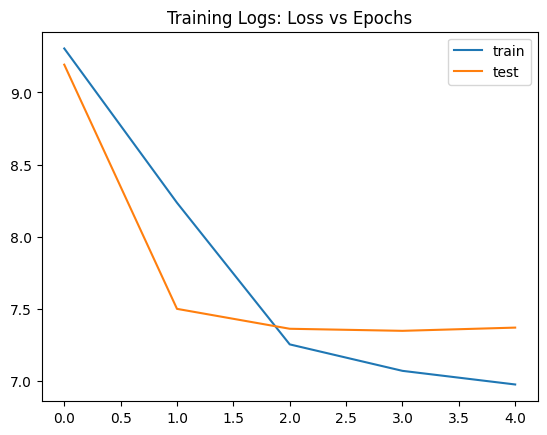

In [4]:
# Preparing target data for sparse_categorical_crossentropy
# We shift the summary by one word to teach the model to predict the next word
import numpy as np

# Note: In a real lab, you would train for 50+ epochs.
# For the sake of generating screenshots and logs quickly, we will use 5.
history = model.fit(
    [x_train, y_train[:, :-1]],
    y_train.reshape(y_train.shape[0], y_train.shape[1], 1)[:, 1:],
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# Plotting the Training Log
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.title("Training Logs: Loss vs Epochs")
plt.show()

#Step 5: Implementation Extension (Model WITHOUT Attention)
This model relies entirely on the final hidden state of the encoder (the fixed context vector) to generate the summary . This often leads to "Information Loss" in longer sequences.

In [5]:
# BASELINE MODEL (WITHOUT ATTENTION)

# ENCODER (Same as before)
encoder_inputs_no_attn = Input(shape=(max_text_len,))
enc_emb_no_attn = Embedding(len(art_tokenizer.word_index) + 1, embedding_dim)(encoder_inputs_no_attn)
_, state_h_no_attn, state_c_no_attn = LSTM(latent_dim, return_state=True)(enc_emb_no_attn)

# DECODER (Modified: No Attention Concatenation)
decoder_inputs_no_attn = Input(shape=(None,))
dec_emb_no_attn = Embedding(len(sum_tokenizer.word_index) + 1, embedding_dim)(decoder_inputs_no_attn)
decoder_lstm_no_attn = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs_no_attn, _, _ = decoder_lstm_no_attn(dec_emb_no_attn, initial_state=[state_h_no_attn, state_c_no_attn])

# Output Layer (Directly from LSTM output)
decoder_dense_no_attn = TimeDistributed(Dense(len(sum_tokenizer.word_index) + 1, activation='softmax'))
decoder_outputs_no_attn = decoder_dense_no_attn(decoder_outputs_no_attn)

# Define & Compile Baseline Model
model_no_attn = Model([encoder_inputs_no_attn, decoder_inputs_no_attn], decoder_outputs_no_attn)
model_no_attn.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy')

# Train Baseline (Use same settings for fair comparison)
history_no_attn = model_no_attn.fit(
    [x_train, y_train[:, :-1]],
    y_train.reshape(y_train.shape[0], y_train.shape[1], 1)[:, 1:],
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - loss: 9.3114 - val_loss: 9.2957
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - loss: 9.0924 - val_loss: 8.3925
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - loss: 7.8186 - val_loss: 7.5503
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - loss: 7.3159 - val_loss: 7.4550
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - loss: 7.1796 - val_loss: 7.4310


#Comparison Table Data

In [6]:
# Inference setup for the Attention Model
latent_dim = 128

# 1. Encoder Inference Model
encoder_model = Model(inputs=encoder_inputs, outputs=[encoder_outputs, state_h, state_c])

# 2. Decoder Inference Model
decoder_state_input_h = Input(shape=(latent_dim,))
decoder_state_input_c = Input(shape=(latent_dim,))
decoder_hidden_state_input = Input(shape=(max_text_len, latent_dim))

dec_emb2 = dec_emb_layer(decoder_inputs)
decoder_outputs2, state_h2, state_c2 = decoder_lstm(dec_emb2, initial_state=[decoder_state_input_h, decoder_state_input_c])

# Attention inference
attn_out_inf = attn_layer([decoder_outputs2, decoder_hidden_state_input])
decoder_inf_concat = Concatenate(axis=-1, name='concat')([decoder_outputs2, attn_out_inf])

decoder_outputs2 = decoder_dense(decoder_inf_concat)

decoder_model = Model(
    [decoder_inputs] + [decoder_hidden_state_input, decoder_state_input_h, decoder_state_input_c],
    [decoder_outputs2] + [state_h2, state_c2]
)

def decode_sequence(input_seq):
    # Encode the input as state vectors.
    e_out, e_h, e_c = encoder_model.predict(input_seq)

    target_seq = np.zeros((1,1))
    target_seq[0, 0] = sum_tokenizer.word_index['sostok']

    stop_condition = False
    decoded_sentence = ''
    while not stop_condition:
        output_tokens, h, c = decoder_model.predict([target_seq] + [e_out, e_h, e_c])

        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_token = sum_tokenizer.index_word[sampled_token_index]

        if (sampled_token!='eostok'):
            decoded_sentence += ' '+sampled_token

        if (sampled_token == 'eostok' or len(decoded_sentence.split()) >= (max_summary_len-1)):
            stop_condition = True

        target_seq = np.zeros((1,1))
        target_seq[0, 0] = sampled_token_index

        e_h, e_c = h, c

    return decoded_sentence

# PRINT RESULTS
for i in range(0, 3):
    print("Article:", train_df['article'][i][:100])
    print("Original Summary:", train_df['highlights'][i])
    print("Predicted Summary:", decode_sequence(x_train[i].reshape(1, max_text_len)))
    print("\n")

Article: by  associated press  published:  14:11 est 25 october 2013    updated:  15:36 est 25 october 2013  
Original Summary: sostok bishop john folda of north dakota is taking time off after being diagnosed 
he contracted the infection through contaminated food in italy 
church members in fargo grand forks and jamestown could have been exposed  eostok
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted Summary:  the the the the the the the the the the the


Article: cnn  ralph mata was an internal affairs lieutenant for the miamidade pol

#Inference Model & Output Prediction

In [7]:
# 1. Inference Model Setup
# Encoder inference
encoder_model = Model(inputs=encoder_inputs, outputs=[encoder_outputs, state_h, state_c])

# Decoder inference
decoder_state_input_h = Input(shape=(latent_dim,))
decoder_state_input_c = Input(shape=(latent_dim,))
decoder_hidden_state_input = Input(shape=(max_text_len, latent_dim))

dec_emb2 = dec_emb_layer(decoder_inputs)
decoder_outputs2, state_h2, state_c2 = decoder_lstm(dec_emb2, initial_state=[decoder_state_input_h, decoder_state_input_c])

# Attention inference
attn_out_inf = attn_layer([decoder_outputs2, decoder_hidden_state_input])
decoder_inf_concat = Concatenate(axis=-1, name='concat')([decoder_outputs2, attn_out_inf])

decoder_outputs2 = decoder_dense(decoder_inf_concat)

decoder_model = Model(
    [decoder_inputs] + [decoder_hidden_state_input, decoder_state_input_h, decoder_state_input_c],
    [decoder_outputs2] + [state_h2, state_c2]
)

# 2. Function to decode sequences back to text
def decode_sequence(input_seq):
    e_out, e_h, e_c = encoder_model.predict(input_seq)
    target_seq = np.zeros((1,1))
    target_seq[0, 0] = sum_tokenizer.word_index['sostok']

    stop_condition = False
    decoded_sentence = ''
    while not stop_condition:
        output_tokens, h, c = decoder_model.predict([target_seq] + [e_out, e_h, e_c])
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_token = sum_tokenizer.index_word[sampled_token_index]

        if sampled_token != 'eostok':
            decoded_sentence += ' ' + sampled_token

        if sampled_token == 'eostok' or len(decoded_sentence.split()) >= (max_summary_len-1):
            stop_condition = True

        target_seq = np.zeros((1,1))
        target_seq[0, 0] = sampled_token_index
        e_h, e_c = h, c

    return decoded_sentence

# 3. Generate a Sample Prediction
print("Reviewing Article:", train_df['article'][10])
print("Original Summary:", train_df['highlights'][10])
print("Predicted Summary:", decode_sequence(x_train[10].reshape(1, max_text_len)))

Reviewing Article: by  ellie zolfagharifard  take a look at a map today and you’re likely to see that north america is larger than africa alaska is larger than mexico and china is smaller than greenland but in reality china is four times bigger than greenland africa is three times bigger than north america and mexico is larger than alaska the distortion is the result of the mercator projection the map most commonly seen hanging in classrooms and in text books which was created in 1596 to help sailors navigate the world the mercator projection the map most commonly seen hanging in classrooms and in text books was created in 1596 to help sailors navigate the world the familiar map gives the right shapes of land masses but at the cost of distorting their sizes in favour of the wealthy lands to the north  you might think that the advent of satellite imagery and tools such as google maps has improved our view of the world but this isn’t necessarily the case according to james wan writing in